In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)

# Check for GPU, otherwise use CPU
# device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# 1. Load MNIST Data (Train and Test)
# We use 'None' as transform initially because we want to manipulate raw tensors first
# If you want look up transforms and it will show you how to do normalization etc here
train_data_raw = datasets.MNIST(root='./data', train=True, download=True, transform=None)
test_data_raw = datasets.MNIST(root='./data', train=False, download=True, transform=None)

def filter_and_prepare(dataset):
    # Access the data (N, 28, 28) and targets (N)
    x = dataset.data.float() / 255.0  # Normalize to 0-1
    y = dataset.targets
    
    # 2. Filter for 0s and 1s and 2s
    mask = (y == 0) | (y == 1) | (y == 2)
    x_filtered = x[mask]
    y_filtered = y[mask]
    
    # 3. Relabel
    y_labels = torch.tensor([[1,0,0] if y0 == 0 else [0,1,0] if y0==1 else [0,0,1] for y0 in y_filtered]).unsqueeze(1)
    
    # Add Channel Dimension for CNN: (N, 28, 28) -> (N, 1, 28, 28)
    # PyTorch uses (Batch, Channel, Height, Width) unlike Keras' (B, H, W, C)
    x_filtered = x_filtered.unsqueeze(1)
    
    return x_filtered, y_labels

# Prepare Train and Test tensors
x_train, y_train = filter_and_prepare(train_data_raw)
x_test, y_test = filter_and_prepare(test_data_raw)

print(f"Filtered Train Shape: {x_train.shape}") # Should be (N, 1, 28, 28)
print(f"Filtered Test Shape: {x_test.shape}")
print(f"Label shape: {y_train.shape}, type: {type(y_train)}")


Filtered Train Shape: torch.Size([18623, 1, 28, 28])
Filtered Test Shape: torch.Size([3147, 1, 28, 28])
Label shape: torch.Size([18623, 1, 3]), type: <class 'torch.Tensor'>


In [26]:
# Create DataLoaders (The iterator that feeds the model)
train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

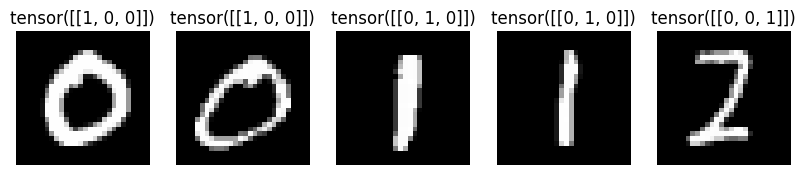

In [27]:
# Pull one batch to visualize
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # PyTorch image is (1, 28, 28), we need to squeeze to (28, 28) for plotting
    plt.imshow(images[i].squeeze(), cmap='gray')
    label_name = labels[i]
    plt.title(f"{label_name}")
    plt.axis('off')
plt.show()

In [28]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()
        
        # Layer 1: Conv (1 input channel -> 32 output channels)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Layer 2: Conv (32 -> 64)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        
        # Layer 3: Fully Connected
        # Note: We need to calculate the input size for the linear layer.
        # 28x28 -> conv1(3x3) -> 26x26 -> pool -> 13x13
        # 13x13 -> conv2(3x3) -> 11x11 -> pool -> 5x5
        # So flattened size is 64 channels * 5 * 5 = 1600
        self.fc1 = nn.Linear(64 * 5 * 5, 64)
        self.out = nn.Linear(64, 3) # Output 3 values
        self.sigmoid = nn.Sigmoid() # Squash to 0-1
        
    def forward(self, x):
        # Layer 1
        x = self.pool(self.relu(self.conv1(x)))
        # Layer 2
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten: (Batch, 64, 5, 5) -> (Batch, 1600)
        x = x.view(x.size(0), -1) 
        
        # Dense Layers
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.out(x))
        return x

model = BinaryCNN().to(device)
print(model)

BinaryCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1600, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=3, bias=True)
  (sigmoid): Sigmoid()
)


In [47]:
# Loss and Optimizer
criterion = nn.L1Loss() # Mean absolute error
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []

print("Starting Training...")

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Move data to GPU/MPS if available
        images, labels = images.to(device), labels.to(device)
        
        # 1. Zero Gradients (Clear previous step's history)
        optimizer.zero_grad()
        
        # 2. Forward Pass (Make prediction)
        outputs = model(images)
        outputs = outputs.unsqueeze(1)
        
        # 3. Calculate Loss (Compare prediction to ground truth)
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass (Calculate gradients via Backprop)
        loss.backward()
        
        # 5. Optimizer Step (Update weights)
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print("Training Complete!")

Starting Training...
Epoch [1/10], Loss: 0.0230
Epoch [2/10], Loss: 0.0036
Epoch [3/10], Loss: 0.0027
Epoch [4/10], Loss: 0.0023
Epoch [5/10], Loss: 0.0019
Epoch [6/10], Loss: 0.0018
Epoch [7/10], Loss: 0.0014
Epoch [8/10], Loss: 0.0013
Epoch [9/10], Loss: 0.0012
Epoch [10/10], Loss: 0.0011
Training Complete!


Final Test Accuracy: 10740.42%


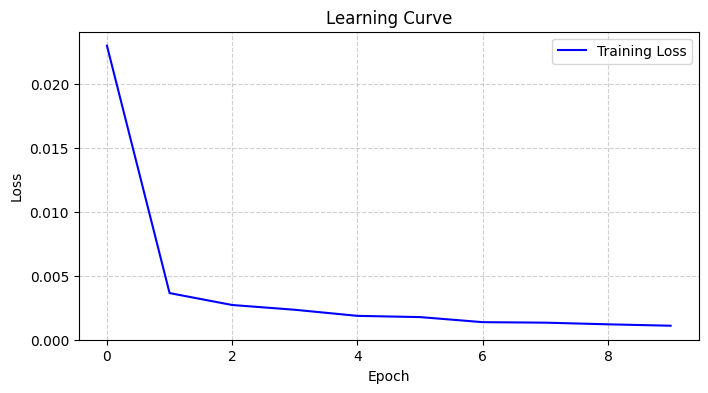

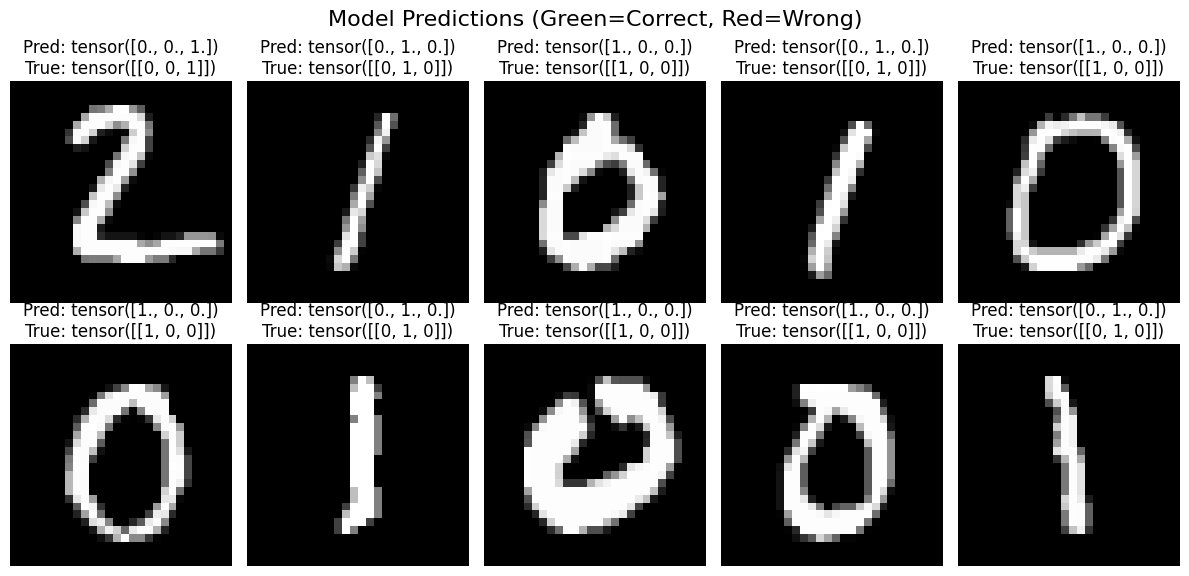

In [48]:
# 1. Switch to Evaluation Mode
model.eval()

correct = 0
total = 0

# 2. Turn off Gradient Tracking
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Test Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Get one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make predictions
images_device = images.to(device)
outputs = model(images_device)
preds = (outputs > 0.5).float()

# Plot a 2x5 Grid
plt.figure(figsize=(12, 6))
plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=16)

for idx in range(10):
    ax = plt.subplot(2, 5, idx + 1) # Simple 1-10 index
    
    # Process image (remove channel dim, convert to numpy)
    img_np = images[idx].squeeze().numpy()
    ax.imshow(img_np, cmap='gray')
    ax.axis('off')
    
    # Determine labels
    pred_val = preds[idx]
    true_val = labels[idx]
    
    ax.set_title(f"Pred: {pred_val}\nTrue: {true_val}", fontsize=12)

plt.tight_layout()
plt.show()